In [17]:
import pymc as pm
import arviz as az
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal
import pytensor
import pytensor.tensor as pt

np.random.seed(42)
T = 100
rainfall = np.random.uniform(0, 20, T)
runoff_coeff = 0.5

noise = np.random.normal(0, 1, T)
exog = runoff_coeff * rainfall + noise

exog[0] = 0
flow_c = scipy.signal.lfilter(b=[1.0], a=[1.0, -0.8], x=exog)
sensor_noise = np.random.normal(0, 2, T) # The sensor is shaking
flow_true = flow_c + sensor_noise # REMOVED THE +10

flow_centered = flow_true - flow_true.mean()
rainfall_centered = rainfall-rainfall.mean()

C:\Users\digit\AppData\Local\Temp\ipykernel_8144\1658248292.py:31: DeprecationWarning: Scan return signature will change. Updates dict will not be returned, only the first argument. Pass `return_updates=False` to conform to the new API and avoid this warning
  latent_flow, _ = pytensor.scan( # Using pytensor.scan directly
Sampling: [beta, initial_flow, likelihood, phi, raw_shocks, sigma_obs, sigma_process]


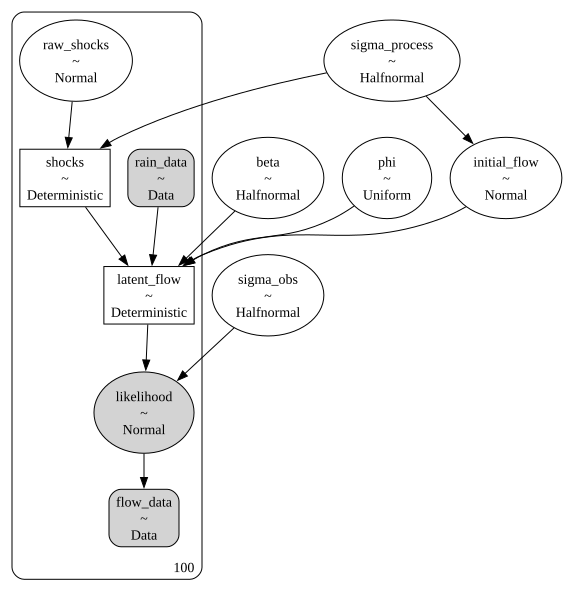

<Axes: xlabel='likelihood'>

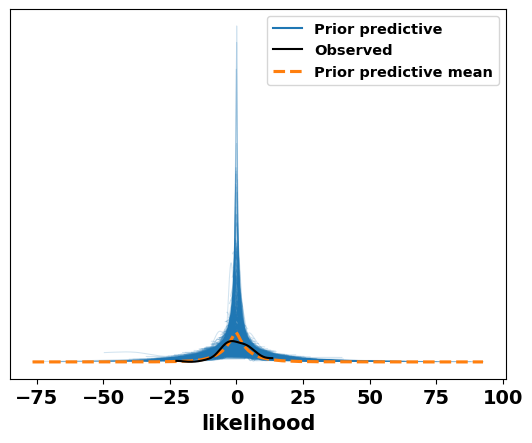

In [18]:
with pm.Model() as m3_arx:
    rain_data = pm.Data("rain_data", rainfall_centered)
    flow_data = pm.Data("flow_data", flow_centered)


    phi = pm.Uniform("phi", 0.0, 1.0)
    #0.5+-0.5 i.e model could be between amnesiac and grw but not <0 or >1

    beta = pm.HalfNormal("beta", sigma=1)
    # beta here is the runoff coeff, we know its positive, we could model as pm.uniform (0,1 bounds)

    #exg = beta * rain_data
    # external exogenous

    sigma_process = pm.HalfNormal("sigma_process", sigma=1)
    # because we are operating on fluctuating component
    sigma_obs = pm.HalfNormal("sigma_obs", sigma=1)
    # because our observed is also centered data not full data

    raw_shocks = pm.Normal("raw_shocks", mu=0, sigma=1, shape=T)
    # NCP Architecture: Separate the magnitude from the distribution
    process_shocks = pm.Deterministic("shocks", raw_shocks * sigma_process)

    initial_flow = pm.Normal("initial_flow", mu=0, sigma=sigma_process)

    def ar_ex_physics(today_rain, today_shock, yesterday_flow, phi, beta):
        today_flow = (phi * yesterday_flow) + (beta * today_rain) + today_shock
        return today_flow


    latent_flow, _ = pytensor.scan( # Using pytensor.scan directly
        fn=ar_ex_physics,
        sequences=[rain_data, process_shocks],
        outputs_info=[initial_flow],
        non_sequences=[phi, beta] # Fixed typo from non_sequenuces
    )
    #baseline day 0

    # positional arguements

    latent_flow = pm.Deterministic("latent_flow", latent_flow)

    likelihood = pm.Normal("likelihood", mu = latent_flow  , sigma = sigma_obs, observed=flow_data)
    # not river data but the errors in our yt that model compares against observed

    # if we define mu = ar+exg instead of using const=exg in pm.AR
    # it means that we are defining the exg NOT ncesessarily as sth that would physically appear/reality
    # but as 'modification' to the sensor data

    #  this is seperation of Latent State (the real physics) from the Observation Equation (the likelihood/sensor)

    prior_checks = pm.sample_prior_predictive(samples=1000, random_seed=42)

display(pm.model_to_graphviz(m3_arx))
az.plot_ppc(prior_checks, group="prior", kind="kde", observed=True)



# good priors, because its a centered data, clustered around 0 and okay to bleed to negative symmetrical

c:\Users\digit\miniconda3\envs\infra_quant\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [phi, beta, sigma_process, sigma_obs, raw_shocks, initial_flow]
Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 227 seconds.
There were 4 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic

Output()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
phi,0.762,0.057,0.655,0.863,0.002,0.001,695.0,1475.0,1.00
beta,0.463,0.053,0.364,0.560,0.001,0.001,1954.0,2358.0,1.00
initial_flow,-7.973,2.379,-12.307,-3.432,0.076,0.045,998.0,1574.0,1.00
sigma_obs,1.745,0.432,0.850,2.503,0.034,0.023,178.0,157.0,1.01
sigma_process,2.510,0.388,1.805,3.243,0.027,0.014,223.0,326.0,1.01


c:\Users\digit\miniconda3\envs\infra_quant\Lib\site-packages\arviz\stats\stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


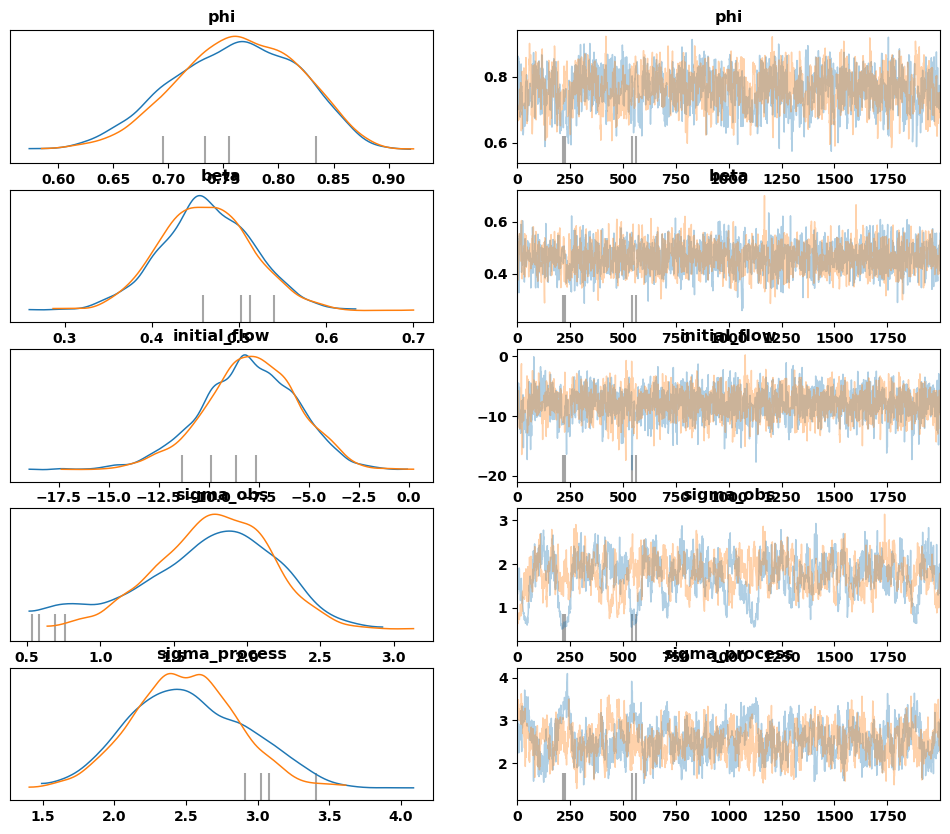

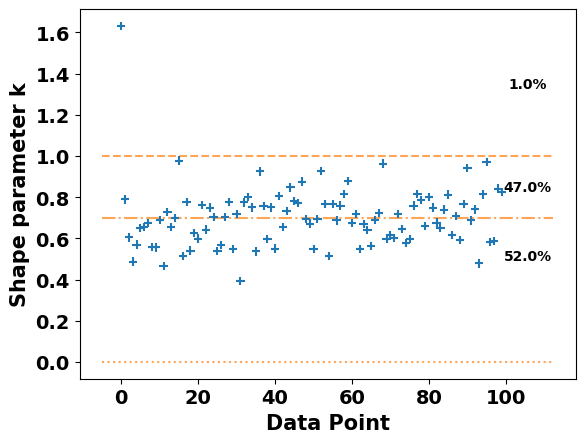

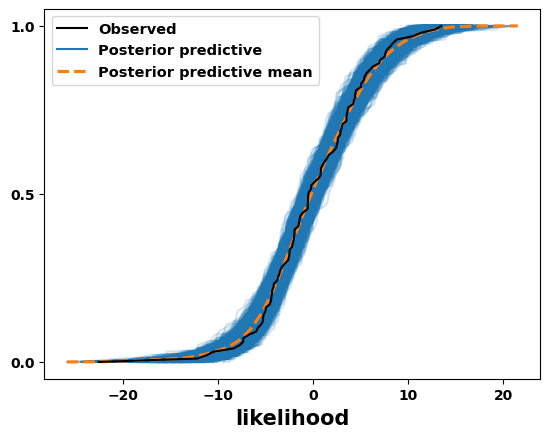

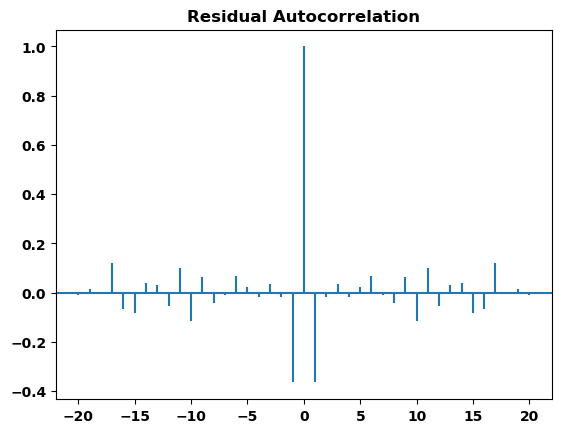

In [ ]:
with m3_arx:
    trace = pm.sample(draws=2000,
                          tune=1000,
                          cores=2, chains=2, target_accept=0.95,
                          random_seed=42,
                          progressbar=False,)

    pm.sample_posterior_predictive(trace, random_seed=42, progressbar=False, extend_inferencedata=True)
    pm.compute_log_likelihood(trace)

display(az.summary(trace, var_names=["phi", "beta", "initial_flow", "sigma_obs", "sigma_process"]))
az.plot_trace(trace, var_names=["phi", "beta", "initial_flow", "sigma_obs", "sigma_process"], compact=False)

#az.plot_energy(trace)
#az.plot_pair(trace, divergences=True)
# no need to look energy and pair if divergence =1

# Put these on their own figures so they don't crash into each other!

az.plot_khat(az.loo(trace), show_bins=True, show_hlines=True)

az.plot_ppc(trace, kind='cumulative', observed=True)
plt.show()

pred_mean = trace.posterior_predictive["likelihood"].mean(dim=["chain", "draw"])
residuals = flow_centered - pred_mean.values
plt.acorr(residuals, maxlags=20)
plt.title("Residual Autocorrelation")
plt.show()

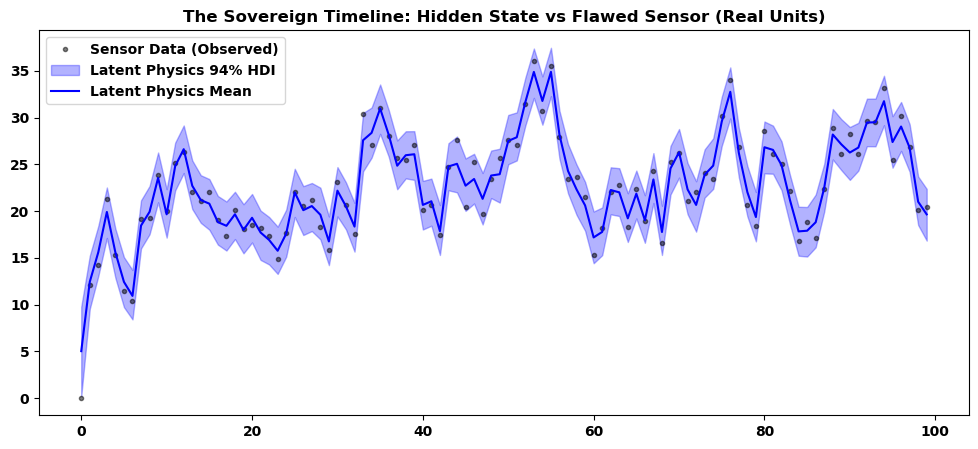

In [20]:
# timeline plot

fig, ax = plt.subplots(figsize=(12, 5))

# Plot the ACTUAL observations, not the centered ones
ax.plot(flow_true, 'k.', label="Sensor Data (Observed)", alpha=0.5)

# The missing baseline
base_level = flow_true.mean()

# Get the Latent Flow (The Hidden River Physics) AND UN-CENTER IT
latent_hdi = az.hdi(trace.posterior["latent_flow"]).latent_flow + base_level
latent_mean = trace.posterior["latent_flow"].mean(dim=["chain", "draw"]) + base_level

# Plot the 94% HDI of the Hidden Physics
ax.fill_between(
    range(T),
    latent_hdi[:, 0], # Lower bound
    latent_hdi[:, 1], # Upper bound
    color="blue", alpha=0.3, label="Latent Physics 94% HDI"
)

# Plot the mean Latent Flow
ax.plot(latent_mean, color="blue", label="Latent Physics Mean")

ax.set_title("The Sovereign Timeline: Hidden State vs Flawed Sensor (Real Units)")
ax.legend()
plt.show()

In [ ]:
#fix: interrogate shape parameter
# define the actual extractoin functoin